


**Author:** Ethan Ligon



In this document we&rsquo;ll work through a simple approach to estimating
Constant Frisch Elasticity (CFE) demand systems.

There are two prerequisites; the first is the `CFEDemands` python
module.  You may have this already, but if not it  can be installed with a simple:



In [ ]:
%pip install -r requirements-estimation.txt

The second prerequisite is a dataset including detailed information on
household expenditures and characteristics.  The structure of that
dataset is detailed in the next section.



## Data



Consider the case in which the data are saved in a google sheet; we&rsquo;ll
turn data from these into `pandas` dataframes.  
There are limits on the allowable size of google sheets (5 million
cells when I last checked), so if your dataset is larger than this you&rsquo;ll need some other
mechanism to get your data into such dataframes.  Even in this latter
case you&rsquo;ll want your dataframes to have a structure that matches the
description given below.



### Structure of the Spreadsheet



An example spreadsheet with data for Uganda can be found at
[https://docs.google.com/spreadsheets/d/1yVLriVpo7KGUXvR3hq_n53XpXlD5NmLaH1oOMZyV0gQ/](https://docs.google.com/spreadsheets/d/1yVLriVpo7KGUXvR3hq_n53XpXlD5NmLaH1oOMZyV0gQ/)

This spreadsheet consists of three worksheets, labeled &ldquo;RDI&rdquo;, &ldquo;FCT&rdquo;,
&ldquo;Household Characteristics&rdquo;, &ldquo;Prices&rdquo;, and a series of different years of food &ldquo;Expenditures&rdquo;.

Each worksheet has the initial three columns labeled &ldquo;i&rdquo;, &ldquo;t&rdquo;, and
&ldquo;m&rdquo;; together these identify an observation uniquely.  The column &ldquo;i&rdquo;
should include a household id; the column &ldquo;t&rdquo; should include an
indicator for the year or period (for those of you with
cross-sectional data these will all take a common value, e.g., 2019);
the column &ldquo;m&rdquo; should be an indicator of &ldquo;market&rdquo;, which may be a
region identifier, or may take a single value (e.g., &ldquo;Malawi&rdquo;).

The triple (i,t,m) will serve as the index of some constructed
dataframes.  It is important not to have **too** many different values
for &ldquo;m&rdquo; (unless you have lots of data and RAM to play with).

Beyond the first three columns, the &ldquo;Expenditures&rdquo; worksheet for a given year should
have one column for each category of expenditures (e.g., &ldquo;Beans&rdquo;, &ldquo;Beef&rdquo;, &ldquo;Beer&rdquo;,&hellip;).

Beyond the first three columns, the &ldquo;Household Characteristics&rdquo; should
have columns corresponding to different elements of the vector of
observable characteristics $z$.  If the data allow, I recommend
constructing observables that match what I have in these data:
namely numbers of different children by age and sex, along with the
logarithm of total household size (&ldquo;log HSize&rdquo;).



### From Sheet to DataFrame to Result Object



We begin by defining a dictionary that contains the spreadsheet key. 
One is provided for the Ugandan example that I wish to work
through.



In [2]:
Uganda_Data = '1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo'

With the spreadsheet defined , grab it and define a couple of
dataframes. (Sheets should be shared with `students@eep153.iam.gserviceaccount.com`):



In [4]:
import pandas as pd
import numpy as np
from ligonlibrary.sheets import read_sheets

x = read_sheets(Uganda_Data,sheet='Food Expenditures (2019)')

# Change 'Uganda' to key of your own sheet in Sheets, above
d = read_sheets(Uganda_Data,sheet="Household Characteristics")
d.columns.name = 'k'

# Data comes in long format; pivot to wide (one column per food)
x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

# NaN in demographic columns means zero people in that category
d = d.fillna(0)
d = d.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]

This gives a dataframe of household characteristics $d$ with a simple structure.



In [5]:
d.head()

,,k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
2101,2019,dakar,5,2,3,7,0,0,0,2,2,0,1,0,3,2,3,3,1,0,2.833213
21010,2019,dakar,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000
21011,2019,dakar,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0.693147
21012,2019,dakar,3,0,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,0,1.609438
2102,2019,dakar,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000


Also a dataframe of log expenditures $y$ with a similarly simple
structure.  Note that any expenditures of zero are dropped and
replaced with a missing value indicator.



In [6]:
y.head()

,,j,"Abats et tripes (foie, rognon, etc.)",Ail,Ananas,Arachide grillée,Arachides décortiquées ou pilées (noflaye),Arachides fraîches en coques,Arachides séchées en coques,"Arôme (Maggi, Jumbo, etc.)",Attiéke,"Aubergine, Courge/Courgette",...,Thé,Tomate fraîche,Tomate séchée,Viande d'autres volailles domestiques,Viande de b__uf,Viande de chèvre,Viande de mouton,Viande de porc,Viande de poulet,Vinaigre /moutarde
i,t,m,,,,,,,,,,,,,,,,,,,,,
221,2019,dakar,7.600902,4.605170,NaN,NaN,6.214608,NaN,NaN,NaN,NaN,4.605170,...,4.60517,6.214608,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,6.214608
222,2019,dakar,NaN,5.298317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.605170,...,NaN,4.605170,NaN,NaN,7.313220,NaN,NaN,NaN,NaN,NaN
223,2019,dakar,NaN,3.912023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.912023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,2019,dakar,6.620073,4.605170,NaN,NaN,NaN,NaN,7.495542,NaN,NaN,NaN,...,NaN,5.298317,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,NaN
225,2019,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Estimation



Let $y_{i}^j$ be log expenditures on food $j$ by household $i$ at a particular time.  We want to estimate a regression that takes the form
$$
      y^j_{i} = A^j(p) + \gamma_j'd_i + \beta_j w_i + \zeta^j_i.
$$
So, a first step is to turn our dataframe for `y` into a series, so we can put it on the left-hand side of this regression.  Then we need to make our dataframe $d$ conform:



In [7]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

### Basic Estimation



Just one line to set up the regression:



In [8]:
from cfe import Regression

result = Regression(y=y,d=d)

And then one line to predict expenditures and estimate most of the things we need:



In [9]:
result.predicted_expenditures()

i       t     m      j                                                                  
221     2019  dakar  Ail                                                                     145.937507
                     Aubergine, Courge/Courgette                                             119.224190
                     Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     113.996219
                     Autres condiments (poivre etc.)                                         123.872860
                     Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)        1754.395865
                                                                                               ...     
234212  2019  thies  Thé                                                                     135.882400
                     Tomate fraîche                                                           90.802638
                     Viande de b__uf                                           

Now we can compare predicted log expenditures with actual:



<Axes: xlabel='yhat', ylabel='y'>

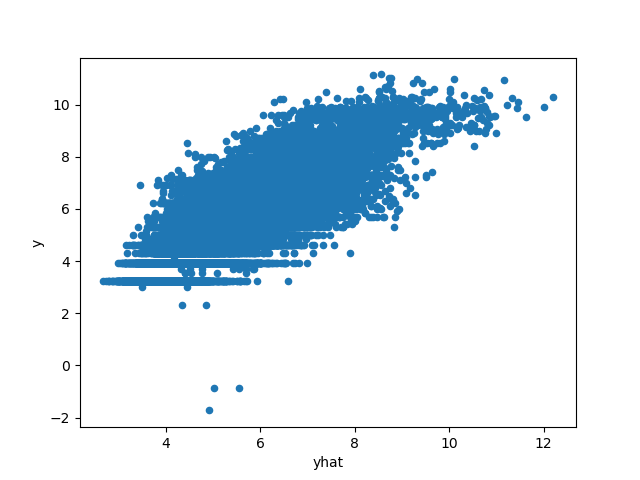

In [10]:
%matplotlib widget
df = pd.DataFrame({'y':y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')

That&rsquo;s all there is to estimation!  Note that we didn&rsquo;t estimate
demands for all goods&mdash;lots of goods didn&rsquo;t have enough observations,
and were automatically dropped.



### Parameters



#### (Relative) Income Elasticity



Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.



In [11]:
result.get_beta().sort_values()

j
Salade (laitue, batavia, etc.)                                         0.254413
Mil                                                                    0.279393
Pain moderne                                                           0.565173
Viande de poulet                                                       0.633828
Poisson frais yaboy ou obo (sardinelle)                                0.676578
Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)    0.692077
Pâte d'arachide                                                        0.711106
Concombre                                                              0.712857
Pâtes alimentaires                                                     0.756995
Feuilles d'oseille (bissap)                                            0.793689
Thé                                                                    0.829663
Gingembre                                                              0.837970
Poisson fumé kétiakh (sardinelle)     

Here we use a plot to visualize, with confidence intervals.



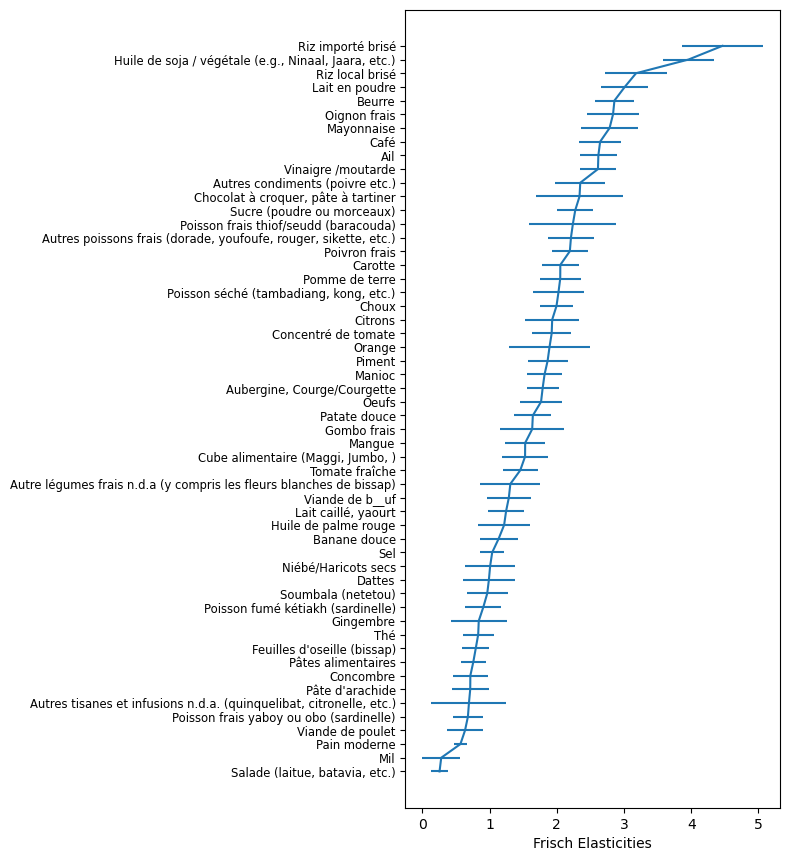

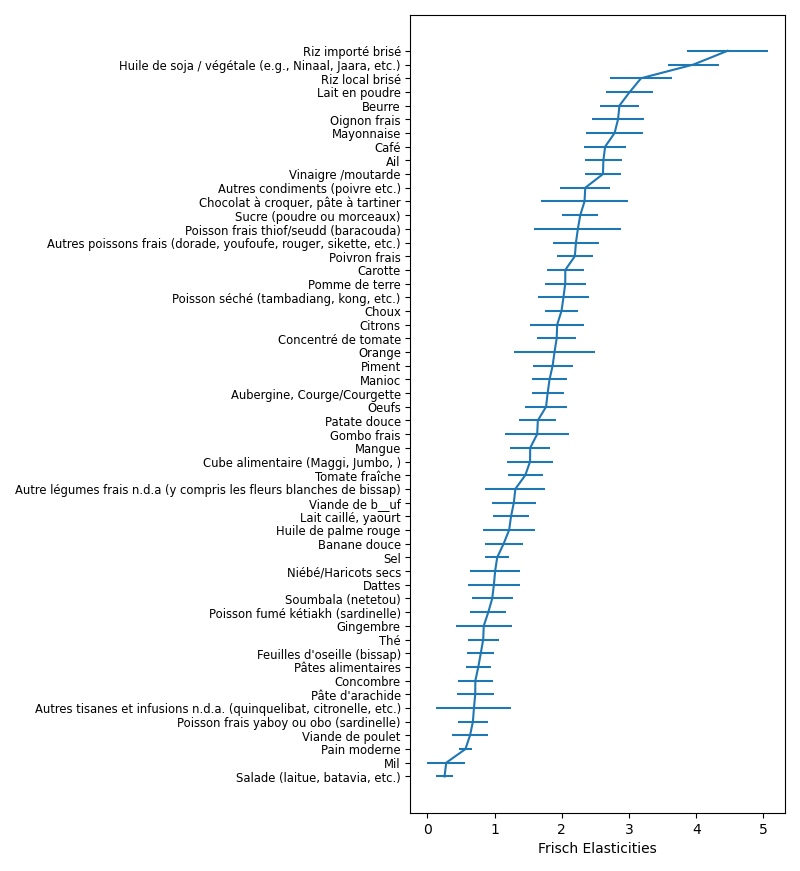

In [12]:
result.graph_beta()

#### Demand and Household Composition



We&rsquo;re particularly interested in the effects of household composition on demand.  These are captured by the $\gamma_j$ parameters in the regression.



In [13]:
result.gamma

k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,
Ail,-0.391805,-0.540041,-0.038018,0.005599,-0.119314,0.470644,0.055575,0.466606,-0.045059,0.523778,-0.008407,0.428874,0.028877,0.455885,0.027141,0.464729,0.028767,0.421124,0.072032,4.346607
"Aubergine, Courge/Courgette",0.321125,0.369397,-0.031768,0.063611,-0.019736,-0.385491,0.075380,-0.369489,0.025632,-0.358525,0.008266,-0.428471,-0.061444,-0.275419,-0.021433,-0.257392,0.025178,-0.276173,0.080532,4.428372
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),0.230888,0.278732,-0.097406,0.171065,0.111702,-0.275480,0.015058,-0.319682,0.132552,-0.120468,0.010928,-0.248723,-0.167219,-0.216765,-0.055459,-0.272201,0.026098,-0.340080,-0.140713,4.428253
Autres condiments (poivre etc.),1.450606,1.487007,-0.078289,0.051023,0.014606,-1.546956,0.097692,-1.586968,0.016887,-1.519723,0.048573,-1.586506,-0.107312,-1.362421,-0.058311,-1.325194,-0.039399,-1.323594,0.140163,4.226014
"Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)",-0.656305,-0.583909,-0.101841,0.112881,0.018591,0.608334,0.027403,0.480617,0.193015,0.604860,0.037100,0.542972,-0.129994,0.685998,-0.081047,0.744805,-0.054027,0.934991,-0.074870,6.933653
"Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)",-0.079391,0.059419,-0.006080,0.062320,0.054793,-0.169879,-0.110330,-0.082465,0.027746,0.040330,-0.117884,-0.071383,-0.006501,0.149086,-0.127525,0.046147,0.335940,0.079889,-0.129520,4.729664
Banane douce,-0.054795,0.017082,-0.069803,0.040277,-0.034814,0.033498,0.047460,-0.057277,0.188376,-0.093330,-0.082482,-0.009324,-0.148814,0.030769,-0.127962,0.031825,0.128710,0.041343,0.366299,6.153402
Beurre,-1.031544,-1.259193,-0.097472,0.106188,0.016785,1.122497,0.266431,1.393006,0.089145,1.266063,0.016218,1.105699,-0.120918,1.164624,-0.163843,1.049182,-0.095101,1.170937,-0.068607,5.495367
Café,1.900350,1.817723,-0.104111,0.132543,0.141668,-1.768096,0.156158,-1.882571,0.064608,-1.754400,-0.057158,-1.879113,-0.099265,-1.779232,-0.082524,-1.775470,-0.095055,-1.799379,-0.050523,5.709043


### Saving Result



You can save the estimated result, using something like



In [17]:
result.to_pickle('my_estimates.pickle')

You can subsequently load this using



In [22]:
import cfe
result = cfe.regression.read_pickle('my_estimates.pickle')
